In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="your key here")
project = rf.workspace("cv-project-v2").project("6-dog-breeds")
version = project.version(1)
dataset = version.download("yolov11")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 143.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to 6-Dog-Breeds-1 in yolov11:: 100%|██████████| 2526/2526 [00:00<00:00, 7419.22it/s]


In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 82.2 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# Load YOLOv11n (nano model, fastest for demos)
model = YOLO("yolo11n.pt")

# Train on Roboflow dataset
model.train(
    data="/content/6-Dog-Breeds-1/data.yaml",  # path to dataset yaml
    epochs=50,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/6-Dog-Breeds-1/data.yaml, degrees=0.0, deterministic=True, device=-1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d7d1b7db9e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [ ]:
# Use best weights from training
model = YOLO("/content/runs/detect/train/weights/best.pt")

# Run inference on an image
results = model.predict("/content/6-Dog-Breeds-1/test/images/beagle_121_jpg.rf.85452dd1344ff69c03ba9af16d7561c7.jpg", save=True)


image 1/1 /content/6-Dog-Breeds-1/test/images/beagle_100_jpg.rf.af45b4f63f130278cc527889843a8320.jpg: 640x640 2 Beagles, 11.1ms
Speed: 2.8ms preprocess, 11.1ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2


In [ ]:
from ultralytics import YOLO

# Load your trained model (replace with your best weights path)
model = YOLO("runs/detect/train/weights/best.pt")

# Export directly to TensorFlow Lite (FP32)
model.export(format="tflite")

# Export with INT8 quantization (recommended for mobile)
model.export(format="tflite", int8=True)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (5.2 MB)

ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 2.1s, saved as 'runs/detect/train/weights/best.onnx' (10.2 MB)

TensorFlow SavedModel: starting export with tensorflow 2.20.0...
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...
Saved artifact at 'runs/detect/train/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 10, 8400), dtype=tf.float32, name=None)
Captures:
  137976603356880: TensorSpec(shape=(4, 2), dtype=tf.int32, 

'runs/detect/train/weights/best_saved_model/best_int8.tflite'

Input details: [{'name': 'images', 'index': 0, 'shape': array([  1, 640, 640,   3], dtype=int32), 'shape_signature': array([  1, 640, 640,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'Identity', 'index': 559, 'shape': array([   1,   10, 8400], dtype=int32), 'shape_signature': array([   1,   10, 8400], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Model input shape: [  1 640 640   3]
Raw output shape: (1, 10, 8400)
Detections shape: (8400, 10)

--- Debug Info ---
Box coords range   — min: -0.0058, max: 1.0009
Class scores range — min: 0.0000, max: 0.7240
Max confidence: 0.7240
Top 5 score

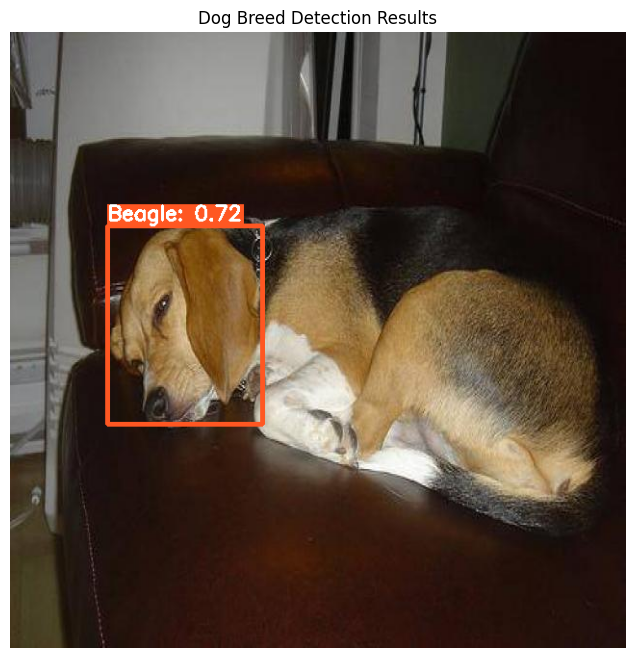

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Path to your custom YOLO11n TFLite model
TFLITE_MODEL_PATH = "/content/runs/detect/train/weights/best_saved_model/best_int8.tflite"

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL_PATH)
interpreter.allocate_tensors()

# Get input/output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:", input_details)
print("Output details:", output_details)

# Dog breed classes
DOG_BREED_CLASSES = ["Beagle", "bullDog", "corgi", "goldenRetriever", "husky", "pomeranian"]

COLORS = [
    (255, 87,  34),  # Beagle          — deep orange
    (33,  150, 243), # bullDog         — blue
    (76,  175,  80), # corgi           — green
    (255, 193,   7), # goldenRetriever — amber
    (156,  39, 176), # husky           — purple
    (  0, 188, 212), # pomeranian      — cyan
]

def non_max_suppression(boxes, scores, classes, score_threshold=0.5, iou_threshold=0.45):
    """Apply NMS to filter overlapping boxes."""
    boxes_list, scores_list, classes_list = [], [], []

    for i in range(len(boxes)):
        if scores[i] >= score_threshold:
            boxes_list.append(boxes[i])
            scores_list.append(float(scores[i]))
            classes_list.append(classes[i])

    if not boxes_list:
        return [], [], []

    indices = cv2.dnn.NMSBoxes(boxes_list, scores_list, score_threshold, iou_threshold)

    if len(indices) > 0:
        indices = indices.flatten()
        return ([boxes_list[i] for i in indices],
                [scores_list[i] for i in indices],
                [classes_list[i] for i in indices])
    return [], [], []

def preprocess_image(image, input_size):
    """Preprocess image for YOLO input."""
    h, w = image.shape[:2]
    scale = min(input_size[0] / w, input_size[1] / h)
    new_w, new_h = int(w * scale), int(h * scale)

    resized = cv2.resize(image, (new_w, new_h))
    padded = np.full((input_size[1], input_size[0], 3), 114, dtype=np.uint8)

    start_x = (input_size[0] - new_w) // 2
    start_y = (input_size[1] - new_h) // 2
    padded[start_y:start_y + new_h, start_x:start_x + new_w] = resized

    return padded, scale, start_x, start_y

# Load test image
img_path = "/content/6-Dog-Breeds-1/test/images/beagle_136_jpg.rf.bcfe89b21081702c9e9d089e3d979b5d.jpg"
image = cv2.imread(img_path)
if image is None:
    raise FileNotFoundError(f"Could not load image: {img_path}")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
original_height, original_width = image_rgb.shape[:2]

# Get input shape
input_shape = input_details[0]['shape']
input_height, input_width = input_shape[1], input_shape[2]
print(f"Model input shape: {input_shape}")

# Preprocess
processed_image, scale, pad_x, pad_y = preprocess_image(image_rgb, (input_width, input_height))

# Prepare input
if input_details[0]['dtype'] == np.uint8:
    input_data = np.expand_dims(processed_image, axis=0).astype(np.uint8)
else:
    input_data = np.expand_dims(processed_image, axis=0).astype(np.float32) / 255.0

# Run inference
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

# Extract output
output_data = interpreter.get_tensor(output_details[0]['index'])
print(f"Raw output shape: {output_data.shape}")

# Skip dequantization if model is float32
output_scale, output_zero_point = output_details[0]['quantization']
if output_scale != 0.0:
    output_data = (output_data.astype(np.float32) - output_zero_point) * output_scale

detections = output_data[0].T  # Shape: (8400, 10)
print(f"Detections shape: {detections.shape}")

# Debug info
print(f"\n--- Debug Info ---")
print(f"Box coords range   — min: {detections[:, :4].min():.4f}, max: {detections[:, :4].max():.4f}")
print(f"Class scores range — min: {detections[:, 4:].min():.4f}, max: {detections[:, 4:].max():.4f}")
print(f"Max confidence: {detections[:, 4:].max():.4f}")
print(f"Top 5 scores: {np.sort(detections[:, 4:].max(axis=1))[::-1][:5]}")
print(f"------------------\n")

# Parse detections
boxes, scores, classes = [], [], []
confidence_threshold = 0.5

for detection in detections:
    x_center, y_center, width, height = detection[:4]
    class_scores = detection[4:]

    max_class_idx = np.argmax(class_scores)
    max_confidence = float(class_scores[max_class_idx])

    if max_confidence >= confidence_threshold:
        # Coords are normalized (0-1), scale to input pixel space first
        x_center *= input_width
        y_center *= input_height
        width    *= input_width
        height   *= input_height

        # Convert cx,cy,w,h → x1,y1,w,h
        x1 = x_center - width  / 2
        y1 = y_center - height / 2
        w  = width
        h  = height

        # Map from padded 640x640 space back to original image
        x1 = (x1 - pad_x) / scale
        y1 = (y1 - pad_y) / scale
        w  = w / scale
        h  = h / scale

        # Clamp to image bounds
        x1 = max(0, min(x1, original_width))
        y1 = max(0, min(y1, original_height))
        w  = min(w, original_width  - x1)
        h  = min(h, original_height - y1)

        boxes.append([int(x1), int(y1), int(w), int(h)])
        scores.append(max_confidence)
        classes.append(max_class_idx)

print(f"Found {len(boxes)} detections before NMS")

# NMS + Draw
if boxes:
    final_boxes, final_scores, final_classes = non_max_suppression(
        boxes, scores, classes,
        score_threshold=confidence_threshold,
        iou_threshold=0.45
    )
    print(f"Found {len(final_boxes)} detections after NMS")

    result_image = image_rgb.copy()

    for i, (box, score, cls) in enumerate(zip(final_boxes, final_scores, final_classes)):
        x, y, w, h = box
        x2, y2 = x + w, y + h

        color = COLORS[cls % len(COLORS)]

        cv2.rectangle(result_image, (x, y), (x2, y2), color, 3)

        label = f"{DOG_BREED_CLASSES[cls]}: {score:.2f}"
        print(f"Detection {i+1}: {label} at [{x}, {y}, {x2}, {y2}]")

        (text_width, text_height), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        cv2.rectangle(result_image, (x, y - text_height - 6), (x + text_width, y), color, -1)
        cv2.putText(result_image, label, (x, y - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    # Plot once after all boxes are drawn
    plt.figure(figsize=(12, 8))
    plt.imshow(result_image)
    plt.axis("off")
    plt.title("Dog Breed Detection Results")
    plt.show()

else:
    print("No detections above threshold.")
    # Show best suppressed guess
    best_idx = np.argmax(detections[:, 4:].max(axis=1))
    best_cls = np.argmax(detections[best_idx, 4:])
    best_conf = detections[best_idx, 4:][best_cls]
    print(f"Best suppressed detection: {DOG_BREED_CLASSES[best_cls]} @ {best_conf:.4f}")

    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title(f"No Detections (best guess: {DOG_BREED_CLASSES[best_cls]} @ {best_conf:.4f})")
    plt.show()

In [ ]:
# ---- Post-training INT8 Quantization ----
import tensorflow as tf

# Load the saved model
converter = tf.lite.TFLiteConverter.from_saved_model("/content/runs/detect/train/weights/best_saved_model")

# Enable optimizations for INT8 quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# (Optional) Representative dataset function
# Helps calibrate ranges for INT8 quantization
import numpy as np
def representative_dataset():
    for _ in range(100):
        # Replace with real sample images later
        data = np.random.rand(1, 640, 640, 3).astype(np.float32)
        yield [data]

converter.representative_dataset = representative_dataset

# Ensure INT8 input/output
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

# Convert to TFLite model
tflite_model = converter.convert()

# Save the quantized model
with open("yolo11n_int8_dog.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Quantized INT8 TFLite model saved as yolo11n_int8.tflite")

✅ Quantized INT8 TFLite model saved as yolo11n_int8.tflite
